In [29]:
!rm -rf laboro_tomato laboro_tomato.zip laboro_tomato.zip.1 yolo_dataset
!wget -q http://assets.laboro.ai.s3.amazonaws.com/laborotomato/laboro_tomato.zip
!unzip -oq laboro_tomato.zip -d laboro_tomato
!find laboro_tomato -maxdepth 3

laboro_tomato
laboro_tomato/laboro_tomato
laboro_tomato/laboro_tomato/annotations
laboro_tomato/laboro_tomato/annotations/test.json
laboro_tomato/laboro_tomato/annotations/train.json
laboro_tomato/laboro_tomato/test
laboro_tomato/laboro_tomato/test/IMG_20191215_111404.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111951.jpg
laboro_tomato/laboro_tomato/test/IMG_1277.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111631.jpg
laboro_tomato/laboro_tomato/test/IMG_1131.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111816.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_112711.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111152.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_110647.jpg
laboro_tomato/laboro_tomato/test/IMG_1175.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111554.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111601.jpg
laboro_tomato/laboro_tomato/test/IMG_20191215_111559.jpg
laboro_tomato/laboro_tomato/test/IMG_1173.jpg
laboro_tomato/laboro_tomato/te

In [30]:
!pip install pycocotools ultralytics -q

In [31]:
from pycocotools.coco import COCO

train_ann_path = "laboro_tomato/laboro_tomato/annotations/train.json"
test_ann_path  = "laboro_tomato/laboro_tomato/annotations/test.json"

coco_train = COCO(train_ann_path)
coco_test  = COCO(test_ann_path)

print("TRAIN — images:", len(coco_train.imgs), "| annotations:", len(coco_train.anns))
print("TEST  — images:", len(coco_test.imgs), "| annotations:", len(coco_test.anns))

loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
TRAIN — images: 643 | annotations: 7781
TEST  — images: 161 | annotations: 1996


In [32]:
from PIL import Image, ImageOps
import os, shutil
from pathlib import Path

merge_map = {
    'b_fully_ripened': 'fully_ripened', 'l_fully_ripened': 'fully_ripened',
    'b_half_ripened': 'half_ripened',   'l_half_ripened': 'half_ripened',
    'b_green': 'green',                 'l_green': 'green',
}
final_classes = ['green', 'half_ripened', 'fully_ripened']
class_to_idx = {c: i for i, c in enumerate(final_classes)}

def convert_split_fixed(coco, img_src_dir, split_name, out_root="yolo_dataset"):
    img_out_dir = Path(out_root) / "images" / split_name
    lbl_out_dir = Path(out_root) / "labels" / split_name
    img_out_dir.mkdir(parents=True, exist_ok=True)
    lbl_out_dir.mkdir(parents=True, exist_ok=True)

    cat_id_to_name = {c['id']: c['name'] for c in coco.cats.values()}

    for img_id, img_info in coco.imgs.items():
        file_name = img_info['file_name']
        coco_w, coco_h = img_info['width'], img_info['height']

        src_path = os.path.join(img_src_dir, file_name)
        dst_path = img_out_dir / file_name

        with Image.open(src_path) as im:
            im_fixed = ImageOps.exif_transpose(im)  # fixes rotated phone photos
            if not dst_path.exists():
                im_fixed.save(dst_path)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        lines = []
        for ann in coco.loadAnns(ann_ids):
            old_name = cat_id_to_name[ann['category_id']]
            new_name = merge_map[old_name]
            cls_idx = class_to_idx[new_name]

            x, y, w, h = ann['bbox']
            cx = (x + w / 2) / coco_w
            cy = (y + h / 2) / coco_h
            nw = w / coco_w
            nh = h / coco_h
            lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path = lbl_out_dir / (Path(file_name).stem + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print(f"{split_name}: {len(coco.imgs)} images converted -> {img_out_dir}")

convert_split_fixed(coco_train, "laboro_tomato/laboro_tomato/train", "train")
convert_split_fixed(coco_test,  "laboro_tomato/laboro_tomato/test",  "test")

train: 643 images converted -> yolo_dataset/images/train
test: 161 images converted -> yolo_dataset/images/test


In [33]:
import random
random.seed(42)

src_img_dir = Path("yolo_dataset/images/train")
src_lbl_dir = Path("yolo_dataset/labels/train")

all_stems = [f.stem for f in src_img_dir.glob("*.jpg")]
random.shuffle(all_stems)

n_val = int(len(all_stems) * 0.15)
val_stems = set(all_stems[:n_val])
train_stems = set(all_stems[n_val:])

for split, stems in [("train", train_stems), ("val", val_stems)]:
    img_out = Path(f"yolo_dataset/images/{split}_final")
    lbl_out = Path(f"yolo_dataset/labels/{split}_final")
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for stem in stems:
        shutil.copy(src_img_dir / f"{stem}.jpg", img_out / f"{stem}.jpg")
        shutil.copy(src_lbl_dir / f"{stem}.txt", lbl_out / f"{stem}.txt")

shutil.rmtree("yolo_dataset/images/train")
shutil.rmtree("yolo_dataset/labels/train")
Path("yolo_dataset/images/train_final").rename("yolo_dataset/images/train")
Path("yolo_dataset/labels/train_final").rename("yolo_dataset/labels/train")
Path("yolo_dataset/images/val_final").rename("yolo_dataset/images/val")
Path("yolo_dataset/labels/val_final").rename("yolo_dataset/labels/val")

print("Train:", len(list(Path("yolo_dataset/images/train").glob("*.jpg"))))
print("Val:", len(list(Path("yolo_dataset/images/val").glob("*.jpg"))))
print("Test:", len(list(Path("yolo_dataset/images/test").glob("*.jpg"))))

Train: 547
Val: 96
Test: 161


In [34]:
yaml_content = f"""path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 3
names: {final_classes}
"""

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print(open("yolo_dataset/data.yaml").read())
print("Exists:", os.path.exists("yolo_dataset/data.yaml"))

path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 3
names: ['green', 'half_ripened', 'fully_ripened']

Exists: True


In [35]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [36]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="yolo_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer="auto",
    lr0=0.01,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    copy_paste=0.3,
    mixup=0.0,
    project="tomato_maturity",
    name="yolov8s_v1",
    seed=42,
    verbose=True,
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v1-2, nbs=64, nms=False, opset

In [37]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.pt")

test_results = best_model.val(
    data="yolo_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    verbose=True,
)

print("\n--- TEST SET RESULTS ---")
print(f"mAP50: {test_results.box.map50:.3f}")
print(f"mAP50-95: {test_results.box.map:.3f}")
print(f"Precision: {test_results.box.mp:.3f}")
print(f"Recall: {test_results.box.mr:.3f}")

print("\nPer-class mAP50:")
for i, name in enumerate(final_classes):
    print(f"  {name}: {test_results.box.ap50[i]:.3f}")

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 100.4±49.4 MB/s, size: 1210.3 KB)
val: Scanning /content/yolo_dataset/labels/test... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 283.5it/s 0.6s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.3s/it 14.5s
                   all        161       1996      0.815      0.793       0.85      0.674
                 green        140       1316      0.884      0.821      0.891      0.689
          half_ripened        119        339      0.733      0.764      0.802      0.643
         fully_ripened         99        341      0.826      0.795      0.857      0.691
Speed: 3.9ms preprocess, 10.2ms inference, 0.0ms loss, 1.7ms postprocess

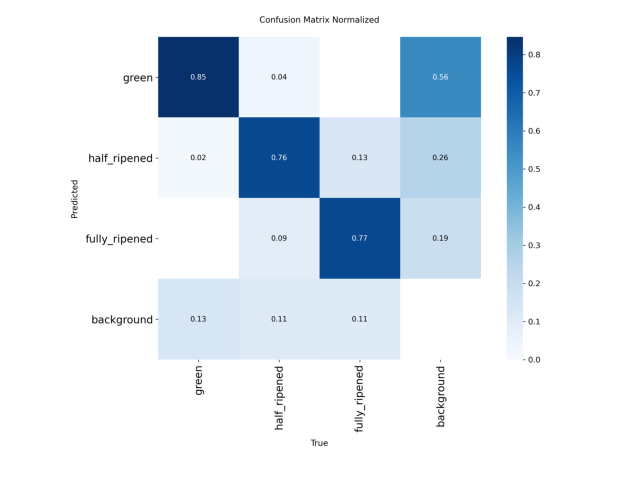

In [38]:
import matplotlib.pyplot as plt
from PIL import Image

# Ultralytics auto-saves a confusion matrix plot during val() — let's find and display it
conf_matrix_path = "runs/detect/val/confusion_matrix_normalized.png"
img = Image.open(conf_matrix_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.show()

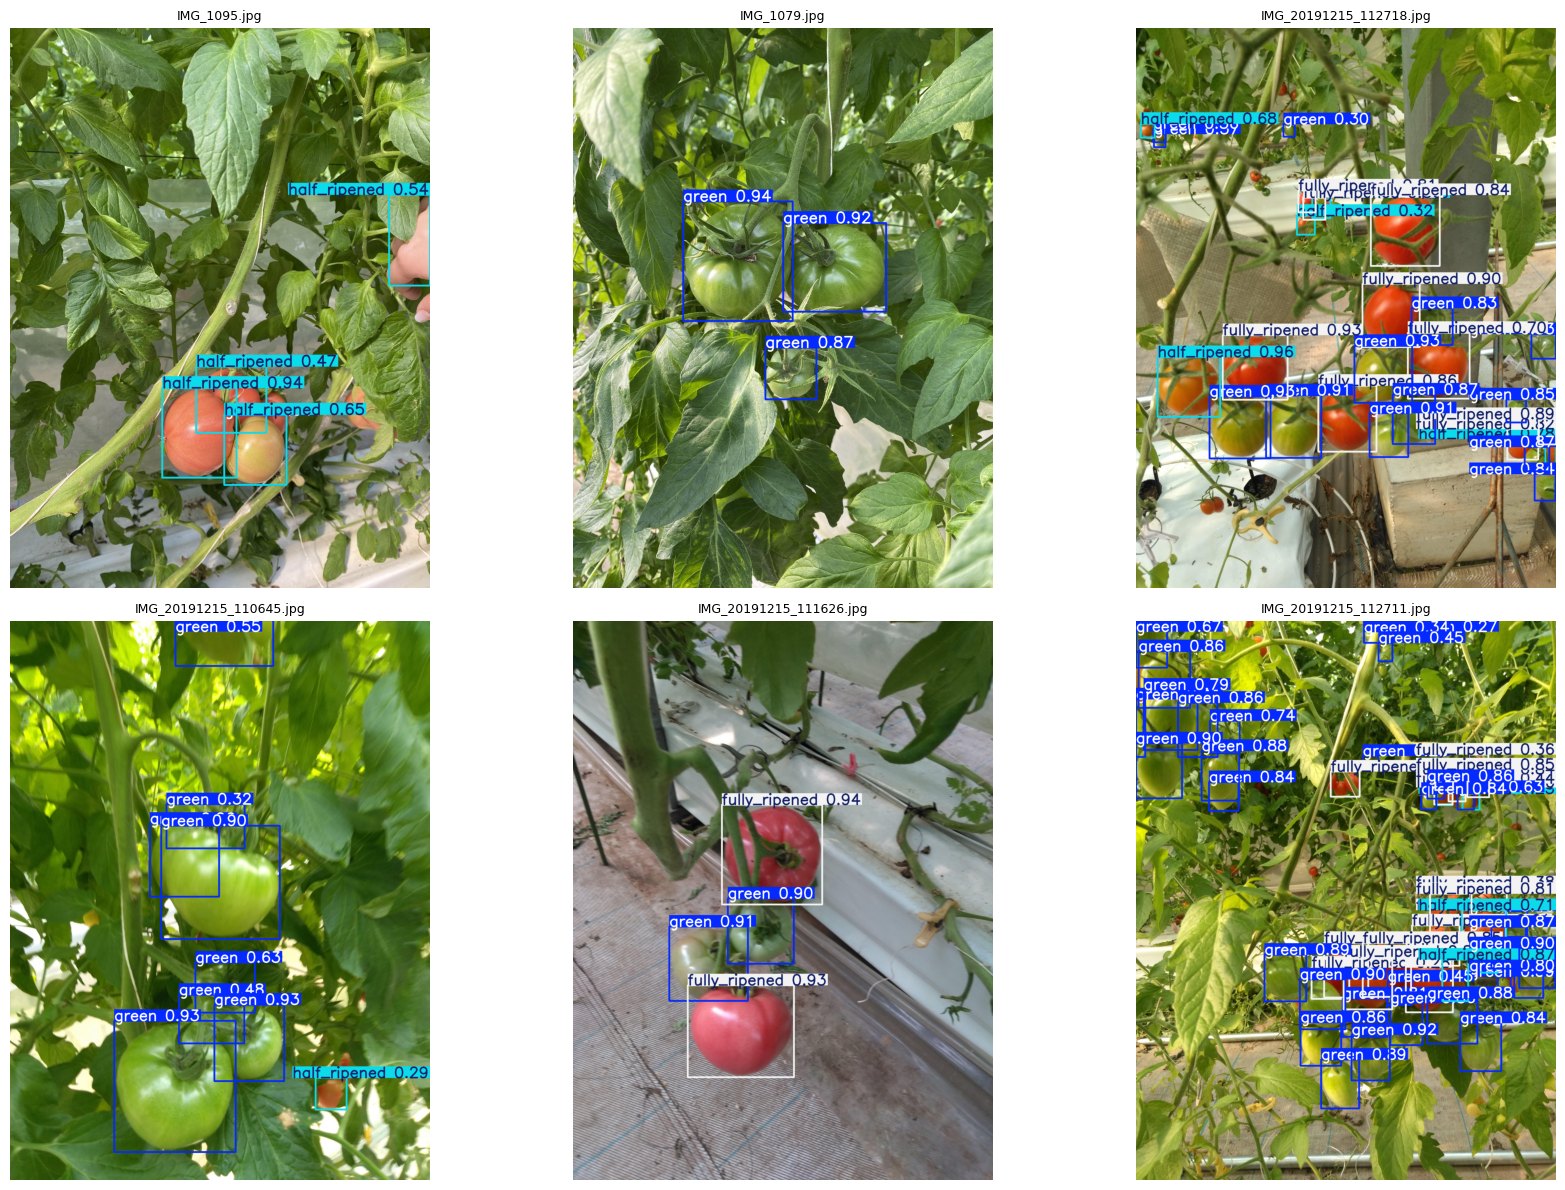

In [39]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
import random

best_model = YOLO("runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.pt")

test_img_dir = Path("yolo_dataset/images/test")
sample_imgs = random.sample(list(test_img_dir.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_path in zip(axes.flat, sample_imgs):
    result = best_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    annotated = result.plot()  # returns BGR numpy array with boxes drawn
    ax.imshow(annotated[..., ::-1])  # convert BGR->RGB
    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [42]:
import shutil
from google.colab import files

# Zip just the essential outputs (trained weights + result plots), not the whole dataset
shutil.make_archive("tomato_maturity_results", "zip", "runs/detect/tomato_maturity")

files.download("tomato_maturity_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from ultralytics import YOLO

model = YOLO("runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.pt")

# Export to ONNX (safest general-purpose default)
model.export(format="onnx", imgsz=640, simplify=True)

# Export to TFLite (for phone/Raspberry Pi)
model.export(format="tflite", imgsz=640)

# Export to OpenVINO (for Intel CPU edge devices)
model.export(format="openvino", imgsz=640)

# CoreML (uncomment if targeting iOS)
# model.export(format="coreml", imgsz=640)

# TensorRT (uncomment ONLY if you have an NVIDIA Jetson/GPU target — won't work generically)
# model.export(format="engine", imgsz=640)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 301ms
Prepared 4 packages in 2.21s
Installed 4 packages in 456ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONN

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.3...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [ DONE] Write Model to runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.tflite (+00:00)

LiteRT: export success ✅ 21.3s, saved as 'runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.tflite' (42.7 MB)

Export complete (22.2s)
Results saved to /content/runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.tflite
Predict:         yolo predict task=detect model=runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.tflite imgsz=640 data=yolo_dataset/data.yaml  
Visualize:       https://netron.app
Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs/detect/tomato_maturity/yolov8s_v1-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr


/usr/lib/python3.13/multiprocessing/popen_fork.py:73: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


OpenVINO: export success ✅ 7.8s, saved as 'runs/detect/tomato_maturity/yolov8s_v1-2/weights/best_openvino_model/' (42.8 MB)

Export complete (9.1s)
Results saved to /content/runs/detect/tomato_maturity/yolov8s_v1-2/weights/best_openvino_model
Predict:         yolo predict task=detect model=runs/detect/tomato_maturity/yolov8s_v1-2/weights/best_openvino_model/ imgsz=640 
Validate:        yolo val task=detect model=runs/detect/tomato_maturity/yolov8s_v1-2/weights/best_openvino_model/ imgsz=640 data=yolo_dataset/data.yaml  
Visualize:       https://netron.app


'runs/detect/tomato_maturity/yolov8s_v1-2/weights/best_openvino_model/'